In [1]:
%pip install scikit-learn


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.1 MB 6.5 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.1 MB 6.8 MB/s eta 0:00:01
   ------------------- -------------------- 3.9/8.1 MB 6.8 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.1 MB 6.8 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.1 MB 6.6 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.1 MB 6.6 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 6.5 MB/s  0:00:01

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- ---------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  battery_id  cycle       chI       chV        chT      disI      disV  \
0         B5      1  1.440147  4.254682  23.988733  1.894407  3.273523   
1         B5      2  1.416595  4.159825  25.665347  1.829949  4.038741   
2         B5      3  1.420272  4.276323  25.407910  1.942105  3.214433   
3         B5      4  1.337680  4.236697  27.069757  2.073577  3.134529   
4         B5      5  1.263946  4.142791  26.478353  2.049885  3.729341   

        disT       BCt        SOH  RUL  
0  32.980834  1.986196  99.309790  219  
1  32.257920  1.986240  99.311985  218  
2  35.134801  1.984252  99.212608  217  
3  32.082988  1.969236  98.461812  216  
4  32.483154  1.974862  98.743106  215  

Columns in dataset:

Index(['battery_id', 'cycle', 'chI', 'chV', 'chT', 'disI', 'disV', 'disT',
       'BCt', 'SOH', 'RUL'],
      dtype='str')

Predicted Future Battery Capacity:

Cycle 250: 0.749782
Cycle 300: 0.499626
Cycle 350: 0.249471
Cycle 400: -0.000685
Cycle 450: -0.250841


C:\Users\Dell\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


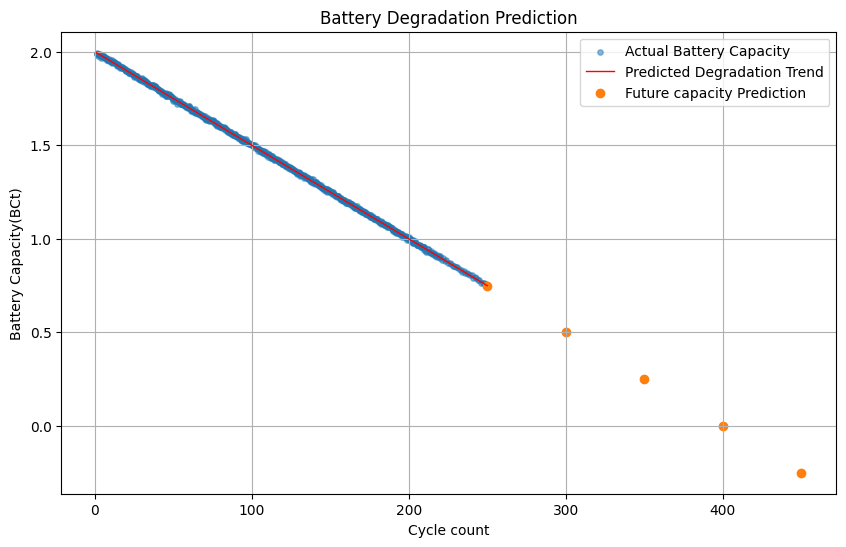

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


from sklearn.linear_model import LinearRegression

df = pd.read_csv("Battery_dataset.csv")

print(df.head())

print("\nColumns in dataset:\n")
print(df.columns)

X = df[["cycle"]]

y = df["BCt"]

model = LinearRegression()

model.fit(X,y)

future_cycles = np.array([250,300,350,400,450])

future_cycles_reshaped = future_cycles.reshape(-1,1)

predicted_capacity = model.predict(future_cycles_reshaped)

print("\nPredicted Future Battery Capacity:\n")

for cycle, capacity in zip(future_cycles, predicted_capacity):

    print(f"Cycle {cycle}: {capacity:4f}")


plt.figure(figsize=(10,6))

plt.scatter(
    X,
    y,
    s = 15,
    alpha = 0.5,
    label = "Actual Battery Capacity"
)

plt.plot(
    X,
    model.predict(X),
    color ="red",
    linewidth = 1,
    label = "Predicted Degradation Trend"
)      

plt.scatter(
    future_cycles,
    predicted_capacity,
    label = "Future capacity Prediction"
)


plt.xlabel("Cycle count")

plt.ylabel("Battery Capacity(BCt)")

plt.title("Battery Degradation Prediction")

plt.legend()

plt.grid(True)

plt.savefig("battery_degradation_prediction.png")

plt.show()
